In [ ]:
# Setup
import os, sys, torch
from argparse import Namespace

repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
sys.path.append(repo_root) if repo_root not in sys.path else None

from revlm.config_utils import configure_args
from revlm import VQAModel, VQADataset
from revlm.editors.auto_q import AutoLayer, ModularityCore


In [ ]:
# Load model & dataset
args = Namespace(config="revlm/config/config.yaml", editor="ike_chain", model_name="qwen3_4b",
                 dataset_name="aokvqa", task="mc", batch_size=1, split="all",
                 rationale=False, cot=False, subsample=100, overwrite=False)
args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
config = configure_args(args, config_path=args.config)

model = VQAModel(config)
dataset = VQADataset(config)
print(f"Model: {config.model.name}, Dataset: {len(dataset)} samples")


In [ ]:
# Print target matrices to understand Vision Q vs Language Q
# Vision Q: cluster by image (same image -> same cluster)
# Language Q: cluster by text (same text -> same cluster)
ModularityCore.print_targets(n=3)


In [ ]:
# Initialize AutoLayer and get candidate layers
# n_samples: number of samples for Q computation
# n_aug: number of augmentations per sample for pure vision/language Q
auto = AutoLayer(config, model, n_samples=2, pool_method = "last")
# , edge_filter="disparity", edge_filter_kwargs={"alpha": 0.005})
layers = auto.get_candidate_layers()


In [ ]:
# Find best layers - computes 5 scores per layer:
# - vision_Q: entangled <img,text> n×n pairs, cluster by image
# - language_Q: entangled <img,text> n×n pairs, cluster by text  
# - harmonic: harmonic mean of vision_Q and language_Q
# - pure_vision_Q: <image, ""> with image augs, cluster by sample
# - pure_language_Q: <blank, text> with text augs, cluster by sample
best, scores = auto.find_best(dataset, layers)


In [ ]:
# Plot all 5 Q scores vs layer index
# Top row: Entangled (Vision Q, Language Q, Harmonic)
# Bottom row: Pure (Pure Vision Q, Pure Language Q)
# Colors: Green = vision layers, Orange = merger layers, Blue = language layers
# Red star = best layer for each metric
auto.plot(scores)


In [ ]:
# Print best layers summary
print("Best layers:")
for metric_name, bests in best.items():
    print(f"\n  {metric_name}:")
    for group, layer in bests.items():
        if layer and layer in scores:
            s = scores[layer]
            bimodal = s.get('bimodal_Q', 0)
            print(f"    {group:15} → ...{layer[-45:]}")
            print(f"      vis={s['vision_Q']:.3f}, lang={s['language_Q']:.3f}, bi={bimodal:.3f}")

In [ ]:
# Cleanup hooks when done
auto.cleanup()


# Load Saved Results (After Running Jobs)

After running `jobs/auto_layer/run.sh`, use the cells below to load aggregated results with error bars.


In [1]:
# Setup
import os, sys, torch
from argparse import Namespace

repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
sys.path.append(repo_root) if repo_root not in sys.path else None

from revlm.config_utils import configure_args
from revlm.editors.auto_q import AutoLayer, BiasLayer


In [2]:
# Load aggregated results from saved runs (with error bars)
model_name = "qwen3"  # Options: "blip", "llava", "qwen3", "qwen3_4b"
pool_method = "mean"     # Options: "mean", "last"

# Paths to saved results
auto_layer_dir = f"results/auto_q_ckpts/{pool_method}/auto_layer_20"  # Q scores
bias_layer_dir = "results/bias_layer"                        # Bias scores

args = Namespace(config="revlm/config/config.yaml", editor="ike_chain", model_name=model_name,
                 dataset_name="aokvqa", task="mc", batch_size=1, split="all",
                 rationale=False, cot=False)
args.device = torch.device("cpu")
config = configure_args(args, config_path=args.config)

# Create AutoLayer for loading Q scores
auto_loader = AutoLayer.__new__(AutoLayer)
auto_loader.config = config
auto_loader.device = args.device

# Create BiasLayer for loading bias scores
bias_loader = BiasLayer.__new__(BiasLayer)
bias_loader.config = config
bias_loader.device = args.device
bias_loader.pool_method = pool_method

# Load Q scores
agg_scores = auto_loader.load_results_k(out_dir=auto_layer_dir)

# Load bias scores
bias_scores = bias_loader.load_results_k(out_dir=bias_layer_dir)

if agg_scores:
    print(f"Loaded Q scores: {len(agg_scores)} layers")
if bias_scores:
    print(f"Loaded bias scores: {len(bias_scores)} layers")


Task evaluation metrics will be saved to results/te/ike_chain/Qwen3-VL-8B-Instruct/aokvqa
Edit evaluation metrics will be saved to results/ee/ike_chain/Qwen3-VL-8B-Instruct/aokvqa
Predictions will be saved to results/pred/Qwen3-VL-8B-Instruct/aokvqa
Post-edit predictions will be saved to results/pred_postedit/ike_chain/Qwen3-VL-8B-Instruct/aokvqa
Unified filename to save: mc_all.json
[AutoLayer] Loading 10 runs...
[AutoLayer] Aggregated 10 runs, 99 layers
[BiasLayer] Loading 10 runs...
[BiasLayer] Aggregated 10 runs, 98 layers
Loaded Q scores: 99 layers
Loaded bias scores: 98 layers


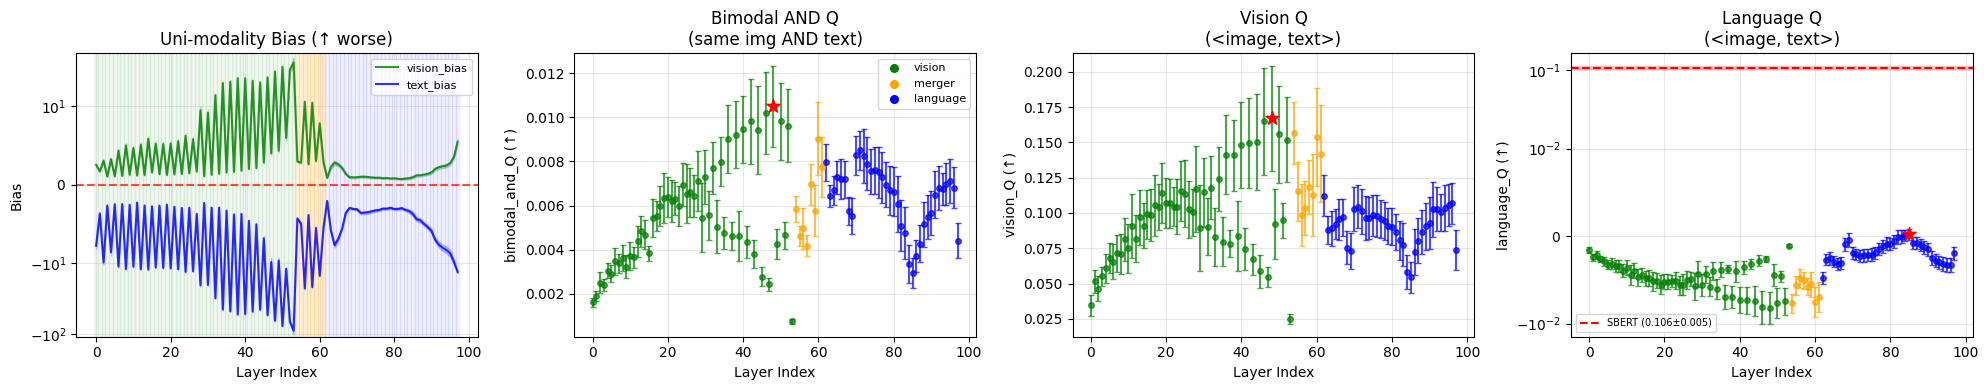

In [3]:
# Plot combined: Bias (col 1) + Q scores (cols 2-6)
if agg_scores:
    # Setup methods for plotting
    auto_loader._classify_layers = lambda layers: AutoLayer._classify_layers(auto_loader, layers)
    auto_loader._is_aggregated = lambda scores: AutoLayer._is_aggregated(auto_loader, scores)
    
    # Plot with optional bias_scores (set to None to skip bias panel)
    AutoLayer.plot(auto_loader, agg_scores, bias_scores=bias_scores)
else:
    print("No saved results found. Run jobs/auto_layer/run.sh first.")
